In [4]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [5]:
conn = sqlite3.connect(r"J:\mlops_revisited\frieght_price_prediction\data\inventory.db")
tables = pd.read_sql_query("select name from sqlite_master where type = 'table'", conn)

In [6]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [7]:
for table in tables['name']:
    df = pd.read_sql_query(f"select * from {table} limit 5", conn)
    display(df)

,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [8]:
vendor_df = pd.read_sql_query("select * from vendor_invoice", conn)
vendor_df.sample(5)

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
2171,7239,REMY COINTREAU USA INC,2024-06-05,10233,2024-05-15,2024-07-02,6282,144517.47,722.59,None
1278,8920,TAKARA SAKE USA INC,2024-03-31,9410,2024-03-18,2024-05-11,171,920.13,4.78,None
3621,11567,CAMPARI AMERICA,2024-09-12,11772,2024-08-23,2024-10-16,9617,75865.43,402.09,None
894,9625,WESTERN SPIRITS BEVERAGE CO,2024-03-02,9015,2024-02-19,2024-04-10,235,4230.72,23.27,None
3030,3252,E & J GALLO WINERY,2024-07-31,11128,2024-07-10,2024-08-29,32713,245491.60,1227.46,None


In [9]:
#check corelation
vendor_df[['Quantity', 'Dollars', 'Freight']].corr()

,Quantity,Dollars,Freight
Quantity,1.000000,0.963831,0.946550
Dollars,0.963831,1.000000,0.985141
Freight,0.946550,0.985141,1.000000


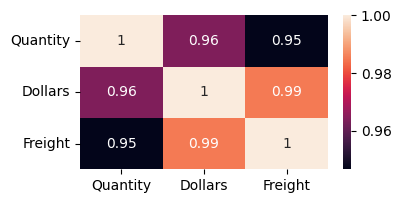

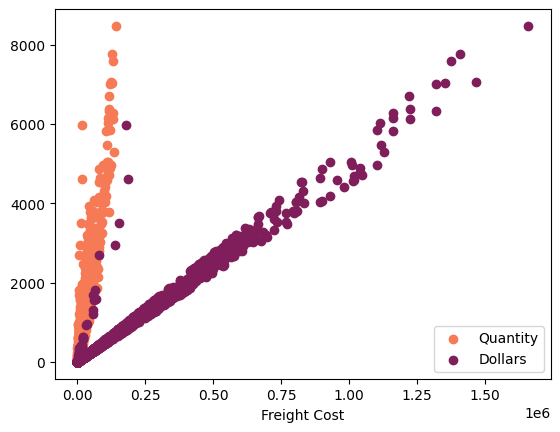

In [10]:
# Relationship between Quantity, Dollars and Freight
plt.figure(figsize=(4,2))
sns.heatmap(vendor_df[['Quantity', 'Dollars', 'Freight']].corr(), annot=True)
plt.show()

plt.scatter(vendor_df['Quantity'], vendor_df['Freight'], color='#f57a55')
plt.scatter(vendor_df['Dollars'], vendor_df['Freight'], color='#7f1e5a')
plt.legend(['Quantity','Dollars'])
plt.xlabel('Freight Cost')
plt.show()

In [11]:
vendor_df['freight_per_unit'] = vendor_df['Freight'] / vendor_df['Quantity']

In [12]:
low_quantity = vendor_df['Quantity'].quantile(0.25)
high_quantity = vendor_df['Quantity'].quantile(0.75)

In [13]:
f"{low_quantity} - {high_quantity}"

'83.0 - 5100.5'

In [14]:
print(vendor_df.loc[vendor_df['Quantity'] < low_quantity, 'freight_per_unit'].mean())
print(vendor_df.loc[vendor_df['Quantity'] > high_quantity, 'freight_per_unit'].mean())

0.09489854253138316
0.049077654690759046


In [15]:
# this means when its ordered in bulk qty then pay less 

### experiment

In [16]:
# Prepare features and target
X = vendor_df[['Quantity', 'Dollars']]
y = vendor_df['Freight']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# Set MLflow tracking
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("freight_price_prediction")

<Experiment: artifact_location='mlflow-artifacts:/654049128111641531', creation_time=1774351685833, experiment_id='654049128111641531', last_update_time=1774351685833, lifecycle_stage='active', name='freight_price_prediction', tags={}>

#### Exp 1: Baseline

In [50]:
with mlflow.start_run():
    # Log preprocessing params
    mlflow.log_param('test_size', 0.2)
    mlflow.log_param('random_state', 42)
    mlflow.log_param('features', ['Quantity', 'Dollars'])
    
    # Initialize Random Forest Regressor
    rf_model = RandomForestRegressor(random_state=42)
    
    # Train the model
    rf_model.fit(X_train, y_train)
    
    #log model params
    mlflow.log_param('model', 'RandomForestRegressor')
    
    # Make predictions
    y_train_pred = rf_model.predict(X_train)
    y_test_pred = rf_model.predict(X_test)
    
    # Calculate metrics
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Log model parameters
    mlflow.log_param('n_estimators', rf_model.n_estimators)
    mlflow.log_param('max_depth', rf_model.max_depth)
    mlflow.log_param('min_samples_split', rf_model.min_samples_split)
    mlflow.log_param('min_samples_leaf', rf_model.min_samples_leaf)
    
    # Log metrics
    mlflow.log_metrics({
        'train_mae': train_mae,
        'train_rmse': train_rmse,
        'train_r2': train_r2,
        'test_mae': test_mae,
        'test_rmse': test_rmse,
        'test_r2': test_r2
    })
    
    # Log the model
    mlflow.sklearn.log_model(rf_model, "random_forest_model")
    
    # log notebook
    import os
    notebook_path = r"J:\mlops_revisited\frieght_price_prediction\experiments\exp1.ipynb"
    os.system(f"jupyter nbconvert --to notebook --execute --inplace {notebook_path}")
    mlflow.log_artifact(notebook_path)
    
    
    #print results
    results = ({
        'train_mae': train_mae,
        'train_rmse': train_rmse,
        'train_r2': train_r2,
        'test_mae': test_mae,
        'test_rmse': test_rmse,
        'test_r2': test_r2
    })
    
    print(results)

{'train_mae': 11.180793272714627, 'train_rmse': 58.52639324849567, 'train_r2': 0.9932476635492653, 'test_mae': 27.645808885229208, 'test_rmse': 138.62117343792318, 'test_r2': 0.9627905784240083}


#### Exp 2: Best Algorithm

In [18]:
# Set MLflow tracking
mlflow.set_experiment("freight_price_prediction_BestAlgorithm")

<Experiment: artifact_location='mlflow-artifacts:/161970139339449151', creation_time=1774351845151, experiment_id='161970139339449151', last_update_time=1774351845151, lifecycle_stage='active', name='freight_price_prediction_BestAlgorithm', tags={}>

In [22]:
import pandas as pd
import numpy as np
import sqlite3
import mlflow
import mlflow.sklearn
import time
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Import algorithms
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

In [23]:
# Dictionary of algorithms with their default parameters
algorithms = {
    # Linear Models
    'Linear Regression': {
        'model': LinearRegression(),
        'family': 'Linear',
        'needs_scaling': False
    },
    'Ridge Regression': {
        'model': Ridge(random_state=42),
        'family': 'Linear',
        'needs_scaling': True
    },
    'Lasso Regression': {
        'model': Lasso(random_state=42),
        'family': 'Linear',
        'needs_scaling': True
    },
    'Elastic Net': {
        'model': ElasticNet(random_state=42),
        'family': 'Linear',
        'needs_scaling': True
    },
    
    # Tree-based Models
    'Decision Tree': {
        'model': DecisionTreeRegressor(random_state=42),
        'family': 'Tree',
        'needs_scaling': False
    },
    'Random Forest': {
        'model': RandomForestRegressor(random_state=42, n_jobs=-1),
        'family': 'Tree',
        'needs_scaling': False
    },
    'Gradient Boosting': {
        'model': GradientBoostingRegressor(random_state=42),
        'family': 'Tree',
        'needs_scaling': False
    },
    'AdaBoost': {
        'model': AdaBoostRegressor(random_state=42),
        'family': 'Tree',
        'needs_scaling': False
    },
    
    # Advanced Tree Models
    'XGBoost': {
        'model': XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
        'family': 'Tree',
        'needs_scaling': False
    },
    'LightGBM': {
        'model': LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
        'family': 'Tree',
        'needs_scaling': False
    },
    
    # Other Models
    'KNN Regressor': {
        'model': KNeighborsRegressor(n_jobs=-1),
        'family': 'Distance',
        'needs_scaling': True
    },
    'SVR': {
        'model': SVR(),
        'family': 'Kernel',
        'needs_scaling': True
    }
}

In [24]:
# Store results list before parent run
results = []

with mlflow.start_run(run_name='all_runs') as parent_run:
    # Log parent-level metadata
    mlflow.log_param('experiment_level', 'Level3_Algorithm_Selection')
    mlflow.log_param('total_algorithms_tested', len(algorithms))
    mlflow.log_param('test_size', 0.2)
    mlflow.log_param('random_state', 42)
    mlflow.log_param('features', ['Quantity', 'Dollars'])
    mlflow.log_param('timestamp', datetime.now().isoformat())
    
    # Loop through algorithms (child runs)
    for algo_name, algo_config in algorithms.items():
        print(f"\n{'='*50}")
        print(f"Testing: {algo_name}")
        print(f"Family: {algo_config['family']}")
        print(f"{'='*50}")
        
        # Create child run under parent
        with mlflow.start_run(run_name=f"{algo_name}", nested=True) as child_run:
            # Log algorithm metadata
            mlflow.log_param('algorithm', algo_name)
            mlflow.log_param('algorithm_family', algo_config['family'])
            mlflow.log_param('needs_scaling', algo_config['needs_scaling'])
            
            # Scale features if needed
            X_train_scaled = X_train.copy()
            X_test_scaled = X_test.copy()
            scaler = None
            
            if algo_config['needs_scaling']:
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train)
                X_test_scaled = scaler.transform(X_test)
                mlflow.log_param('scaling_applied', 'StandardScaler')
            
            # Train model
            model = algo_config['model']
            start_time = time.time()
            model.fit(X_train_scaled, y_train)
            train_time = time.time() - start_time
            
            # Make predictions
            start_time = time.time()
            y_train_pred = model.predict(X_train_scaled)
            y_test_pred = model.predict(X_test_scaled)
            predict_time = time.time() - start_time
            
            # Calculate metrics
            train_mae = mean_absolute_error(y_train, y_train_pred)
            train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
            train_r2 = r2_score(y_train, y_train_pred)
            
            test_mae = mean_absolute_error(y_test, y_test_pred)
            test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
            test_r2 = r2_score(y_test, y_test_pred)
            
            # Cross-validation scores
            cv_scores = cross_val_score(
                model, X_train_scaled, y_train, 
                cv=5, scoring='r2', n_jobs=-1
            )
            cv_r2_mean = cv_scores.mean()
            cv_r2_std = cv_scores.std()
            
            # Log model parameters
            for key, value in model.get_params().items():
                if isinstance(value, (int, float, str, bool)) and not callable(value):
                    try:
                        mlflow.log_param(f"param_{key}", value)
                    except:
                        pass
            
            # Log metrics
            mlflow.log_metrics({
                'train_mae': train_mae,
                'train_rmse': train_rmse,
                'train_r2': train_r2,
                'test_mae': test_mae,
                'test_rmse': test_rmse,
                'test_r2': test_r2,
                'cv_r2_mean': cv_r2_mean,
                'cv_r2_std': cv_r2_std,
                'train_time_seconds': train_time,
                'predict_time_seconds': predict_time,
                'overfitting_gap': train_r2 - test_r2
            })
            
            # Log model
            mlflow.sklearn.log_model(model, f"{algo_name.lower().replace(' ', '_')}_model")
            
            # Store results
            results.append({
                'Algorithm': algo_name,
                'Family': algo_config['family'],
                'Train_R2': train_r2,
                'Test_R2': test_r2,
                'Test_MAE': test_mae,
                'Test_RMSE': test_rmse,
                'CV_R2_Mean': cv_r2_mean,
                'CV_R2_Std': cv_r2_std,
                'Train_Time': train_time,
                'Predict_Time': predict_time,
                'Overfitting_Gap': train_r2 - test_r2,
                'Needs_Scaling': algo_config['needs_scaling']
            })
            
            # Print results
            print(f"✓ Training Time: {train_time:.2f} seconds")
            print(f"✓ Test R²: {test_r2:.4f}")
            print(f"✓ Test MAE: ${test_mae:.2f}")
            print(f"✓ CV R²: {cv_r2_mean:.4f} (±{cv_r2_std:.4f})")
            
            if train_r2 - test_r2 > 0.05:
                print(f"⚠️  Warning: Possible overfitting (gap: {train_r2 - test_r2:.4f})")
    
    # After all child runs, log parent-level summary
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Test_R2', ascending=False)
    
    # Log parent-level summary
    mlflow.log_text(results_df.to_string(), "algorithm_comparison_summary.txt")
    
    # Log best algorithm info
    best_algo = results_df.iloc[0]
    mlflow.log_param('best_algorithm', best_algo['Algorithm'])
    mlflow.log_metric('best_test_r2', best_algo['Test_R2'])
    mlflow.log_metric('best_test_mae', best_algo['Test_MAE'])
    
    print("\n" + "="*80)
    print("PARENT RUN SUMMARY")
    print("="*80)
    print(f"Parent Run ID: {parent_run.info.run_id}")
    print(f"Best Algorithm: {best_algo['Algorithm']}")
    print(f"Best Test R²: {best_algo['Test_R2']:.4f}")
    print(f"Best Test MAE: ${best_algo['Test_MAE']:.2f}")
    print("\nTop 3 Algorithms:")
    for i, row in results_df.head(3).iterrows():
        print(f"  {i+1}. {row['Algorithm']}: R² = {row['Test_R2']:.4f}, MAE = ${row['Test_MAE']:.2f}")


Testing: Linear Regression
Family: Linear
✓ Training Time: 0.26 seconds
✓ Test R²: 0.9700
✓ Test MAE: $24.46
✓ CV R²: 0.9695 (±0.0236)

Testing: Ridge Regression
Family: Linear
✓ Training Time: 0.29 seconds
✓ Test R²: 0.9700
✓ Test MAE: $24.46
✓ CV R²: 0.9695 (±0.0236)

Testing: Lasso Regression
Family: Linear
✓ Training Time: 0.03 seconds
✓ Test R²: 0.9699
✓ Test MAE: $24.33
✓ CV R²: 0.9695 (±0.0235)

Testing: Elastic Net
Family: Linear
✓ Training Time: 0.01 seconds
✓ Test R²: 0.9120
✓ Test MAE: $93.91
✓ CV R²: 0.9120 (±0.0250)

Testing: Decision Tree
Family: Tree
✓ Training Time: 0.17 seconds
✓ Test R²: 0.9355
✓ Test MAE: $33.87
✓ CV R²: 0.9178 (±0.0556)
⚠️  Warning: Possible overfitting (gap: 0.0645)

Testing: Random Forest
Family: Tree
✓ Training Time: 3.05 seconds
✓ Test R²: 0.9628
✓ Test MAE: $27.65
✓ CV R²: 0.9500 (±0.0288)

Testing: Gradient Boosting
Family: Tree
✓ Training Time: 1.64 seconds
✓ Test R²: 0.9657
✓ Test MAE: $24.59
✓ CV R²: 0.9520 (±0.0271)

Testing: AdaBoost
Fam

#### exp3: XGBoost Hyper parameter tuning